In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
data_protein = pd.read_csv('06_regulate_protein.groups.tsv', sep='\t', index_col=0)

In [3]:
data_protein.columns

Index(['CBB_01', 'CBB_02', 'CBB_03', 'rGlyP_07', 'rGlyP_08', 'rGlyP_09',
       'CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08',
       'rGlyP_UP_09', 'CBB_01_imputado', 'CBB_02_imputado', 'CBB_03_imputado',
       'rGlyP_07_imputado', 'rGlyP_08_imputado', 'rGlyP_09_imputado',
       'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length',
       'Gene Ontology (biological process)',
       'Gene Ontology (cellular component)', 'Gene Ontology (GO)',
       'Gene Ontology (molecular function)', 'Gene Ontology IDs', 'KEGG',
       'log2FC', 'p_value', 'neg_log10_p', 'p_adj_fdr', 'regulate', 'color'],
      dtype='object')

In [4]:
main_columns = ['CBB_01', 'CBB_02', 'CBB_03','rGlyP_07', 'rGlyP_08','rGlyP_09',]
num_columns = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']
all_columns = main_columns + num_columns
cepa_CBB = ['CBB_01', 'CBB_02', 'CBB_03']
cepa_rGlyP = ['rGlyP_07', 'rGlyP_08','rGlyP_09']
cepa_CBB_peptido = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03']
cepa_rGlyP_peptido = ['rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']

In [5]:
data_protein = data_protein[main_columns + ['regulate']]

In [6]:
data_protein_sig = data_protein[data_protein['regulate'] != 'no_keep']

In [7]:
data_protein_sig

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,regulate
Entry,,,,,,,
O07451,26.392931,26.320032,26.349343,21.936549,21.201639,20.454058,downregulate
P19911,28.544736,28.658239,28.737080,21.951285,22.064118,22.338290,downregulate
P19923,30.795401,30.736636,30.947578,23.237450,23.587528,23.651911,downregulate
P21725,31.568872,31.275392,31.058808,23.861801,23.752780,23.750439,downregulate
P21726,29.800957,29.342355,29.157569,24.311436,24.363674,23.615257,downregulate
...,...,...,...,...,...,...,...
Q7WXK0,20.732686,20.226470,19.562808,23.400605,23.164602,22.987417,upregulate
Q7WXK3,20.886245,20.214564,19.766349,21.862719,21.745562,20.468196,upregulate
Q7WXK4,20.417137,21.028390,19.647959,21.788028,21.546208,21.585692,upregulate


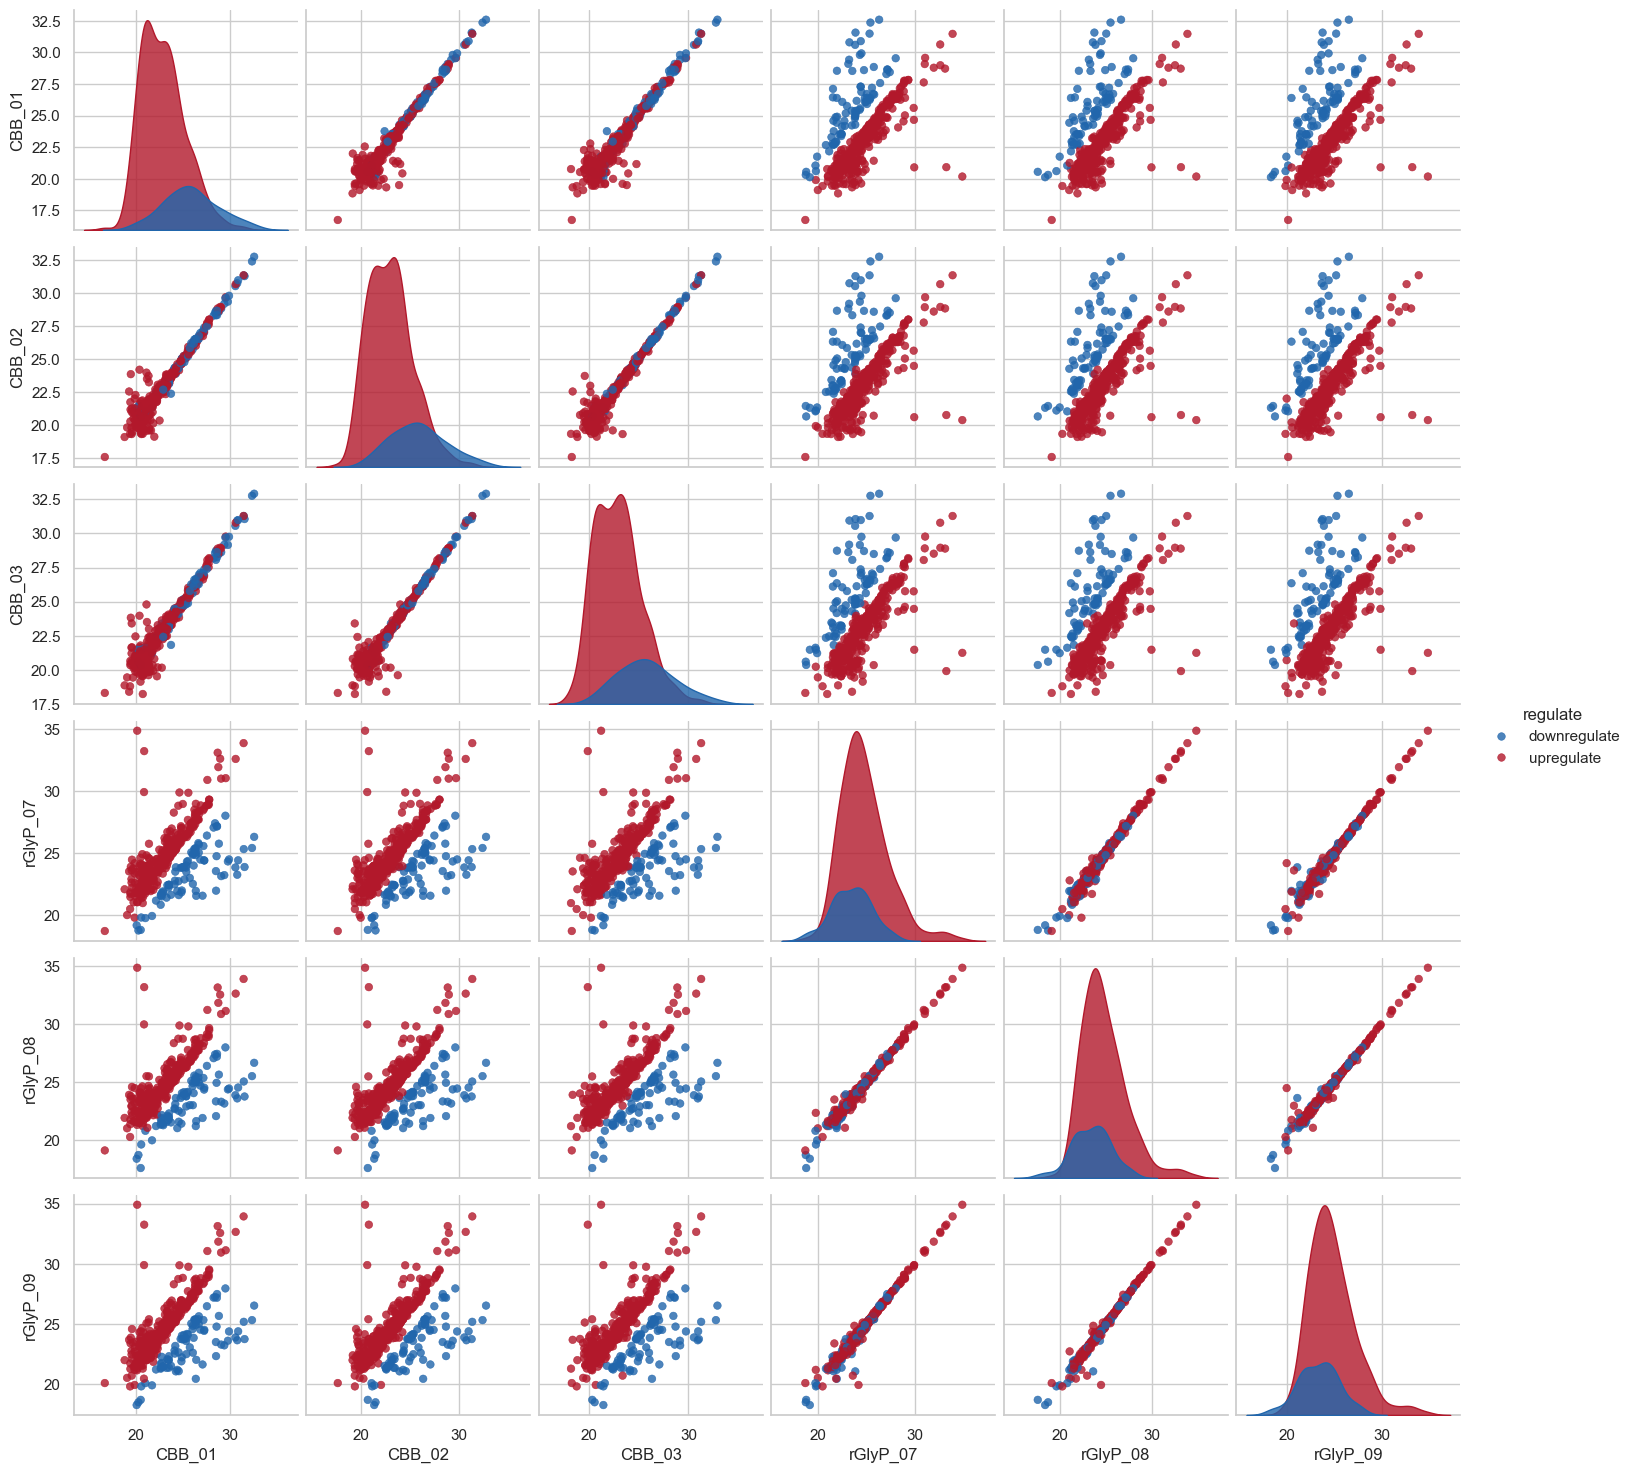

In [8]:
paleta_manual = {"downregulate": '#2166ac', "upregulate":'#b2182b'}

# 2. Creamos el pairplot con ajustes de intensidad
g = sns.pairplot(
    data=data_protein_sig, 
    hue="regulate", 
    palette=paleta_manual,
    corner=False,
    plot_kws={
        'alpha': 0.8,           # Opacidad total (adiós colores pálidos)
        'edgecolor': None,    # Eliminamos el borde blanco que aclara los puntos
        's': 30,              # Tamaño de punto ligeramente más pequeño para nitidez
    },
    diag_kws={
        'alpha': 0.8,         # Las densidades de la diagonal un pelín transparentes para ver solape
        'fill': True,
        'linewidth': 1        # Sin bordes en las curvas de densidad
    }
)
plt.savefig('07_pairplot.png', dpi=300)

In [9]:
data_protein.columns

Index(['CBB_01', 'CBB_02', 'CBB_03', 'rGlyP_07', 'rGlyP_08', 'rGlyP_09',
       'regulate'],
      dtype='object')

In [10]:
data_protein = pd.read_csv('06_regulate_protein.groups.tsv', sep='\t', index_col=0)[main_columns + ['color']]

/Users/pablo1n7/miniconda3/envs/genetica/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/pablo1n7/miniconda3/envs/genetica/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


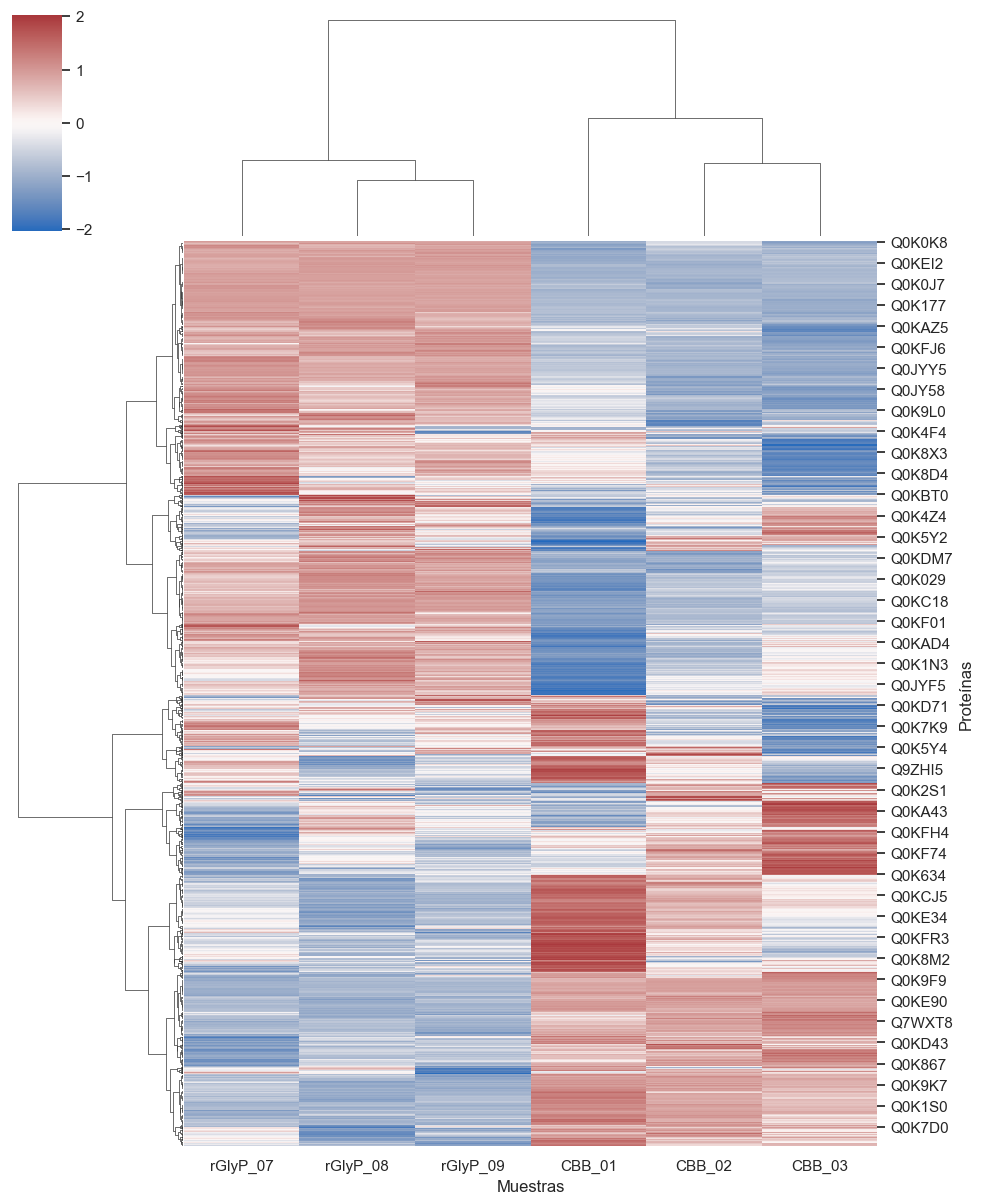

In [11]:
# 3. Extraemos la columna de colores para las filas
colores_filas = data_protein['color']

# 4. Creamos el Clustermap
g = sns.clustermap(
    data_protein[main_columns],
    z_score=0,             
    cmap='vlag',             
    figsize=(10, 12),
    method='ward',            
    metric='euclidean'
)

# Ajustes estéticos
g.ax_heatmap.set_xlabel('Muestras')
g.ax_heatmap.set_ylabel('Proteínas')

plt.savefig('07_clustermap.png', dpi=300)

In [12]:
data_protein

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,color
Entry,,,,,,,
O07451,26.392931,26.320032,26.349343,21.936549,21.201639,20.454058,blue
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,gray
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,gray
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,gray
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,gray
...,...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217,blue
Q83WS0,20.912823,20.766801,19.905533,33.212505,33.180884,33.246544,red
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,gray


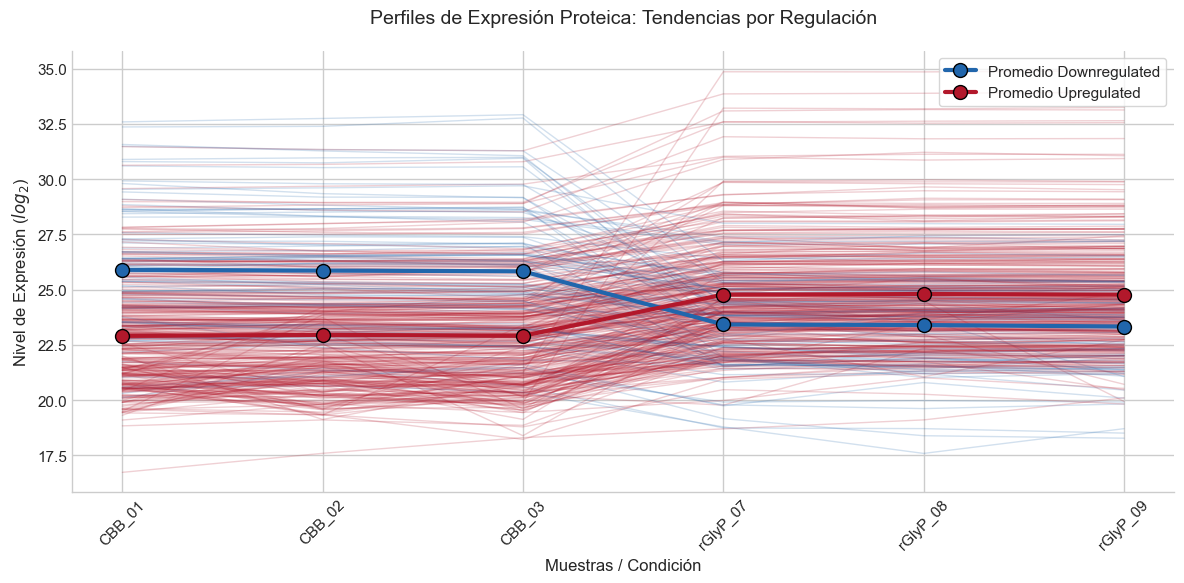

In [13]:
plt.figure(figsize=(12, 6))



plt.style.use('seaborn-v0_8-whitegrid')

data_plot = data_protein[data_protein['color'] != 'gray'].copy()
muestras = ['CBB_01', 'CBB_02', 'CBB_03', 'rGlyP_07', 'rGlyP_08', 'rGlyP_09']

vlag_pal = sns.color_palette("vlag", n_colors=2) # n_colors=2 nos da directamente los dos extremos
color_map = {
    'red': '#b2182b',
    'blue':'#2166ac'
}
# 1. Definimos el mapeo de color a nombre
etiquetas_nombres = {
    '#b2182b': 'Upregulated',
    '#2166ac': 'Downregulated'
}



data_plot['color'] = data_plot['color'].map(color_map).fillna(data_plot['color'])


for idx, fila in data_plot.iterrows():
    plt.plot(
        muestras, 
        fila[muestras], 
        color=fila['color'], 
        alpha=0.2,  
        linewidth=1,
        zorder=1
    )

for c in data_plot['color'].unique():
    subset = data_plot[data_plot['color'] == c]
    mean_profile = subset[muestras].mean()
    
    plt.plot(
        muestras, 
        mean_profile, 
        #color=c,
        color=c, 
        linewidth=3,     # Línea más gruesa para el promedio
        marker='o',      # Puntos en los nodos
        label=f'Promedio {etiquetas_nombres.get(c, c)}',
        zorder=2,
        markerfacecolor=c,
        markeredgecolor='black',
        markersize=10,
    )

plt.title("Perfiles de Expresión Proteica: Tendencias por Regulación", fontsize=14, pad=20)
plt.xlabel("Muestras / Condición", fontsize=12)
plt.ylabel("Nivel de Expresión ($log_{2}$)", fontsize=12) # LaTeX para notación científica
plt.xticks(rotation=45)

plt.legend(loc='upper right', frameon=True, facecolor='white')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('07_perfiles.png', dpi=300)